# 02. Feature EDA

분자 구조 기반 feature 추출 결과를 탐색한다.

**범주 구성**
| 범주 | 접두사 | 설명 |
|------|--------|------|
| 1 | `gc_` | Group Contribution (Joback) |
| 2 | `lg_` | Local Graph (원자/결합 통계) |
| 3 | `gt_` | Global Topology (위상·구성 기술자) |
| 4 | `rd_` | 3D Geometry (형태 기술자, 선택) |
| 5 | `rf_` | Refrigerant-Specific (냉매 특화) |
| 6 | `el_` | Electronic (전자 구조) |

In [18]:
import sys, warnings, os, subprocess
warnings.filterwarnings('ignore')

# 필요 패키지 자동 설치
_REQUIRED = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'rdkit']
for pkg in _REQUIRED:
    try:
        __import__(pkg if pkg != 'rdkit' else 'rdkit.Chem')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

# notebooks/ 기준으로 프로젝트 루트 추가
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import seaborn as sns

# ── 한글 폰트 설정 (Windows: 맑은 고딕) ──────────────────────────────────
def _set_korean_font():
    candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'DejaVu Sans']
    available  = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f'한글 폰트: {font}')
            return
    print('경고: 한글 폰트 없음 → 영문으로 표시됨')

_set_korean_font()
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,   # 마이너스 기호 깨짐 방지
    'font.size': 11,
})

from features import FeaturePipeline

COLORS    = {1: '#2196F3', 0: '#F44336'}
CAT_LABELS = {1: 'label=1 (냉매)', 0: 'label=0 (비냉매)'}

print(f'Project root: {PROJECT_ROOT}')
print('Import 성공')

한글 폰트: Malgun Gothic
Project root: c:\Users\user\Documents\STUDY\Refrigerant_Prediction
Import 성공


---
## 1. 데이터 로드 및 Feature 추출

In [19]:
# 원본 데이터
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
raw = pd.read_csv(os.path.join(DATA_DIR, 'refrigerants_final.csv'))

# valid 컬럼이 문자열 'True'/'False'로 저장된 경우 대응
raw['valid'] = raw['valid'].astype(str).str.lower() == 'true'

df = raw[raw['SMILES'].notna() & raw['valid']].copy().reset_index(drop=True)
print(f'유효 화합물: {len(df)}개  (label=1: {(df["label"]==1).sum()}, label=0: {(df["label"]==0).sum()})')

유효 화합물: 476개  (label=1: 96, label=0: 380)


In [20]:
# Feature 추출 (캐시 사용)
FEAT_PATH = os.path.join(DATA_DIR, 'features_raw.csv')

if os.path.exists(FEAT_PATH):
    feat_df = pd.read_csv(FEAT_PATH)
    print(f'캐시 로드: {feat_df.shape}')
else:
    pipe = FeaturePipeline(include_3d=False)
    feat_df = pipe.transform_batch(df['SMILES'].tolist(), df['identifier'].tolist())
    feat_df['label'] = df['label'].values
    feat_df['group'] = df['group'].values
    feat_df.to_csv(FEAT_PATH, index=False)
    print(f'Feature 추출 완료: {feat_df.shape}')

# 범주별 컬럼 분류
META     = ['identifier', 'label', 'group']
PREFIXES = {'gc': 'Cat1 Group', 'lg': 'Cat2 Graph', 'gt': 'Cat3 Topology',
            'rd': 'Cat4 3D',    'rf': 'Cat5 Refrig', 'el': 'Cat6 Electronic'}
feat_cols = {p: [c for c in feat_df.columns if c.startswith(p+'_')] for p in PREFIXES}

for p, name in PREFIXES.items():
    print(f'  {name:20s}: {len(feat_cols[p]):3d}개')
print(f'  {"합계":20s}: {sum(len(v) for v in feat_cols.values()):3d}개')

캐시 로드: (476, 240)
  Cat1 Group          :  46개
  Cat2 Graph          :  80개
  Cat3 Topology       :  48개
  Cat4 3D             :   0개
  Cat5 Refrig         :  44개
  Cat6 Electronic     :  19개
  합계                  : 237개


---
## 2. NaN 현황

In [21]:
num_cols = [c for c in feat_df.columns if c not in META]
nan_rate = feat_df[num_cols].isna().mean().sort_values(ascending=False)
nan_cols  = nan_rate[nan_rate > 0]

print(f'NaN 포함 컬럼: {len(nan_cols)}개 / 전체 {len(num_cols)}개\n')
for col, rate in nan_cols.items():
    n = feat_df[col].isna().sum()
    # 어떤 화합물인지
    failed = feat_df[feat_df[col].isna()]['identifier'].tolist()
    sample = ', '.join(failed[:5]) + ('...' if len(failed) > 5 else '')
    print(f'  {col:<30} {rate:5.1%}  ({n}건)  예: {sample}')

NaN 포함 컬럼: 13개 / 전체 237개

  gc_joback_Tc_K                 100.0%  (476건)  예: R-41, R-32, R-23, R-40, Ethylene...
  gt_n_other                     99.2%  (472건)  예: R-41, R-32, R-23, R-40, Ethylene...
  gt_ratio_H_C                    4.6%  (22건)  예: R-717, SulfurDioxide, NitrousOxide, HydrogenSulfide, SulfurHexafluoride...
  gt_ratio_hal_C                  4.6%  (22건)  예: R-717, SulfurDioxide, NitrousOxide, HydrogenSulfide, SulfurHexafluoride...
  rf_ratio_F_C                    4.6%  (22건)  예: R-717, SulfurDioxide, NitrousOxide, HydrogenSulfide, SulfurHexafluoride...
  el_q_min                        0.2%  (1건)  예: CarbonMonoxide
  el_q_mean                       0.2%  (1건)  예: CarbonMonoxide
  el_RPCG                         0.2%  (1건)  예: CarbonMonoxide
  el_q_pos_sum                    0.2%  (1건)  예: CarbonMonoxide
  el_q_std                        0.2%  (1건)  예: CarbonMonoxide
  el_RNCG                         0.2%  (1건)  예: CarbonMonoxide
  el_q_max                        0.2%  

In [22]:
# NaN 처리 방침 적용
# 1) gc_joback_Tc_K : 100% NaN → 제거
# 2) gt_n_other     : 99% NaN  → 제거 (거의 정보 없음)
# 3) 나머지 비율 NaN: 0으로 대체 (C=0인 무기물에서 발생)

DROP_COLS = ['gc_joback_Tc_K', 'gt_n_other']
feat_clean = feat_df.drop(columns=DROP_COLS, errors='ignore').copy()
num_cols_clean = [c for c in feat_clean.columns if c not in META]
for c in num_cols_clean:
    feat_clean[c] = feat_clean[c].fillna(0)

print(f'전처리 후 feature 수: {len(num_cols_clean)}개')
print(f'잔여 NaN: {feat_clean[num_cols_clean].isna().sum().sum()}')

전처리 후 feature 수: 235개
잔여 NaN: 0


---
## 3. 대표 화합물 비교
정례·반례 각 유형에서 대표 화합물을 선택해 feature 패턴을 비교한다.

In [23]:
REPS = {
    'R-134a (HFC)':   ('R-134a',  1),
    'R-1234yf (HFO)': ('R-1234yf', 1),
    'R-22 (HCFC)':    ('R-22',     1),
    'R-744 (CO2)':    ('R-744',    1),
    'Benzene':        ('Benzene',  0),
    'Hexane':         ('Hexane',   0),
    'Ethanol':        ('Ethanol',  0),
    'Naphthalene':    ('Naphthalene', 0),
}

# 비교할 핵심 feature
SHOW_FEATS = [
    'gc_F', 'gc_Cl', 'gc_sum_dTc', 'gc_joback_Pc_bar',
    'gt_mw', 'gt_n_F', 'gt_Fsp3', 'gt_n_rings', 'gt_kappa2',
    'rf_fluorination_degree', 'rf_CF3', 'rf_CF2',
    'rf_has_double_bond', 'rf_type_HFC', 'rf_type_HFO', 'rf_type_HC',
    'el_polarizability', 'el_logP', 'el_en_mean', 'el_dipole_gasteiger',
    'lg_mean_is_aromatic', 'lg_algebraic_connectivity',
]

sub = feat_clean.set_index('identifier')
ids = [v[0] for v in REPS.values()]
labels_rep = [v[1] for v in REPS.values()]
rep_names  = list(REPS.keys())

tbl = sub.reindex(ids)[SHOW_FEATS].T
tbl.columns = rep_names

def color_by_label(val):
    """배경색 없이 텍스트만"""
    return ''

def fmt(x):
    if pd.isna(x):  return 'NaN'
    if x == 0:      return '0'
    if abs(x) < 0.001: return f'{x:.2e}'
    return f'{x:.4f}'

tbl_fmt = tbl.applymap(fmt)
display(tbl_fmt.style
    .set_caption('대표 화합물 핵심 Feature 비교')
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '11px')]}]))

,R-134a (HFC),R-1234yf (HFO),R-22 (HCFC),R-744 (CO2),Benzene,Hexane,Ethanol,Naphthalene
gc_F,4.0000,4.0000,2.0000,0,0,0,0,0
gc_Cl,0,0,1.0000,0,0,0,0,0
gc_sum_dTc,0.0700,0.0741,0.0491,0.0332,0.0666,0.1038,0.1071,0.1098
gc_joback_Pc_bar,44.0325,41.3029,50.9476,82.0468,36.1155,55.1963,78.8721,24.9003
gt_mw,102.0300,114.0410,86.4680,44.0090,78.1140,86.1780,46.0690,128.1740
gt_n_F,4.0000,4.0000,2.0000,0,0,0,0,0
gt_Fsp3,1.0000,0.3333,1.0000,0,0,1.0000,1.0000,0
gt_n_rings,0,0,0,0,1.0000,0,0,2.0000
gt_kappa2,1.4464,1.5175,1.4675,1.3800,1.6058,5.0000,1.9600,2.1431
rf_fluorination_degree,0.6667,0.6667,0.5000,0,0,0,0,0


---
## 4. label=1 vs label=0 분포 비교
### 4-1. 판별력 지표 (Effect Size)

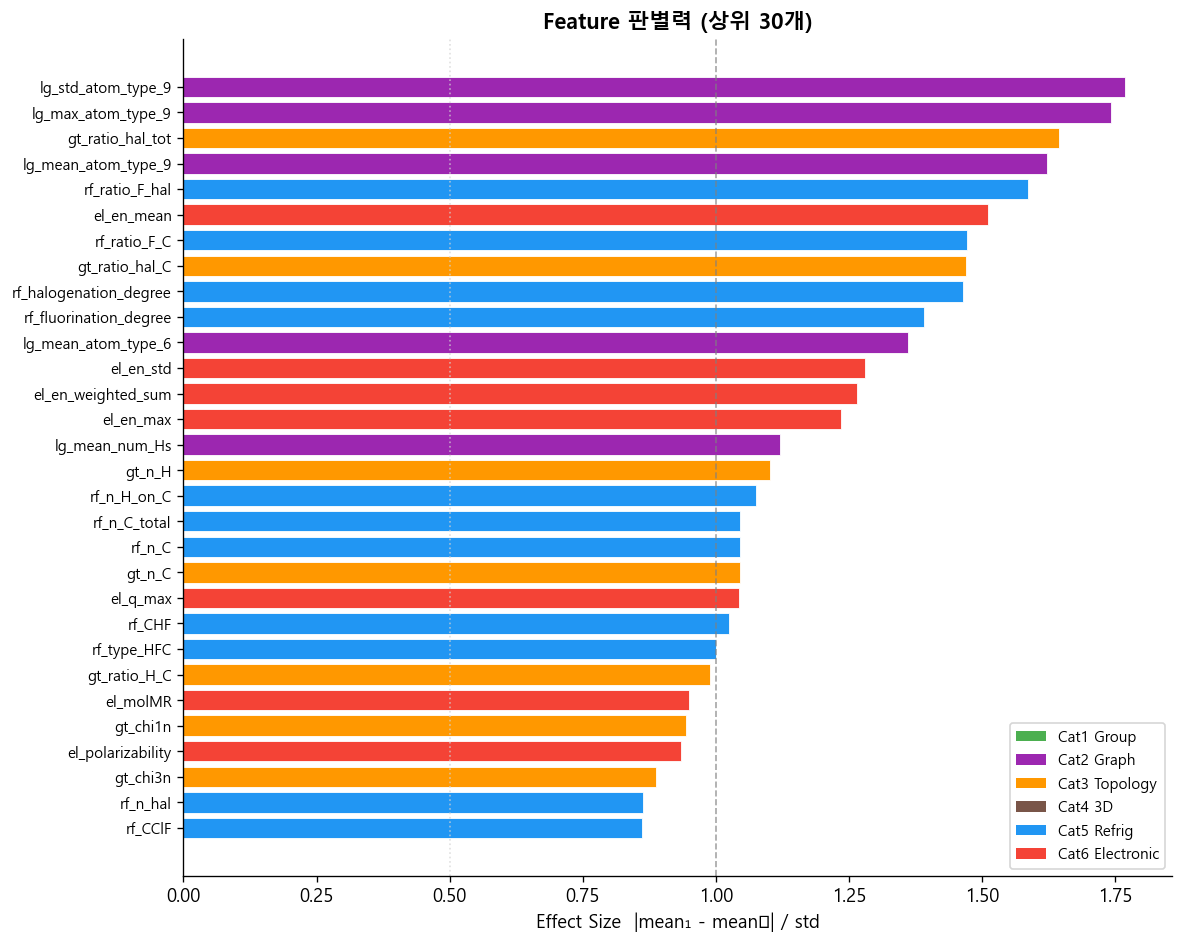

In [24]:
label1 = feat_clean[feat_clean['label'] == 1][num_cols_clean]
label0 = feat_clean[feat_clean['label'] == 0][num_cols_clean]

mean1 = label1.mean()
mean0 = label0.mean()
std_all = feat_clean[num_cols_clean].std() + 1e-8

effect_size = ((mean1 - mean0).abs() / std_all).sort_values(ascending=False)
top30 = effect_size.head(30)

# 범주 색상
PREFIX_COLOR = {
    'gc': '#4CAF50', 'lg': '#9C27B0', 'gt': '#FF9800',
    'rd': '#795548', 'rf': '#2196F3', 'el': '#F44336'
}
bar_colors = [PREFIX_COLOR.get(c.split('_')[0], '#90A4AE') for c in top30.index]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top30)), top30.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=9)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='effect size = 1.0')
ax.axvline(0.5, color='lightgray', linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Effect Size  |mean₁ - mean₀| / std')
ax.set_title('Feature 판별력 (상위 30개)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# 범주 범례
from matplotlib.patches import Patch
legend_elements = [Patch(fc=c, label=PREFIXES[p]) for p, c in PREFIX_COLOR.items() if p in PREFIXES]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 4-2. 주요 Feature 분포 (KDE + boxplot)

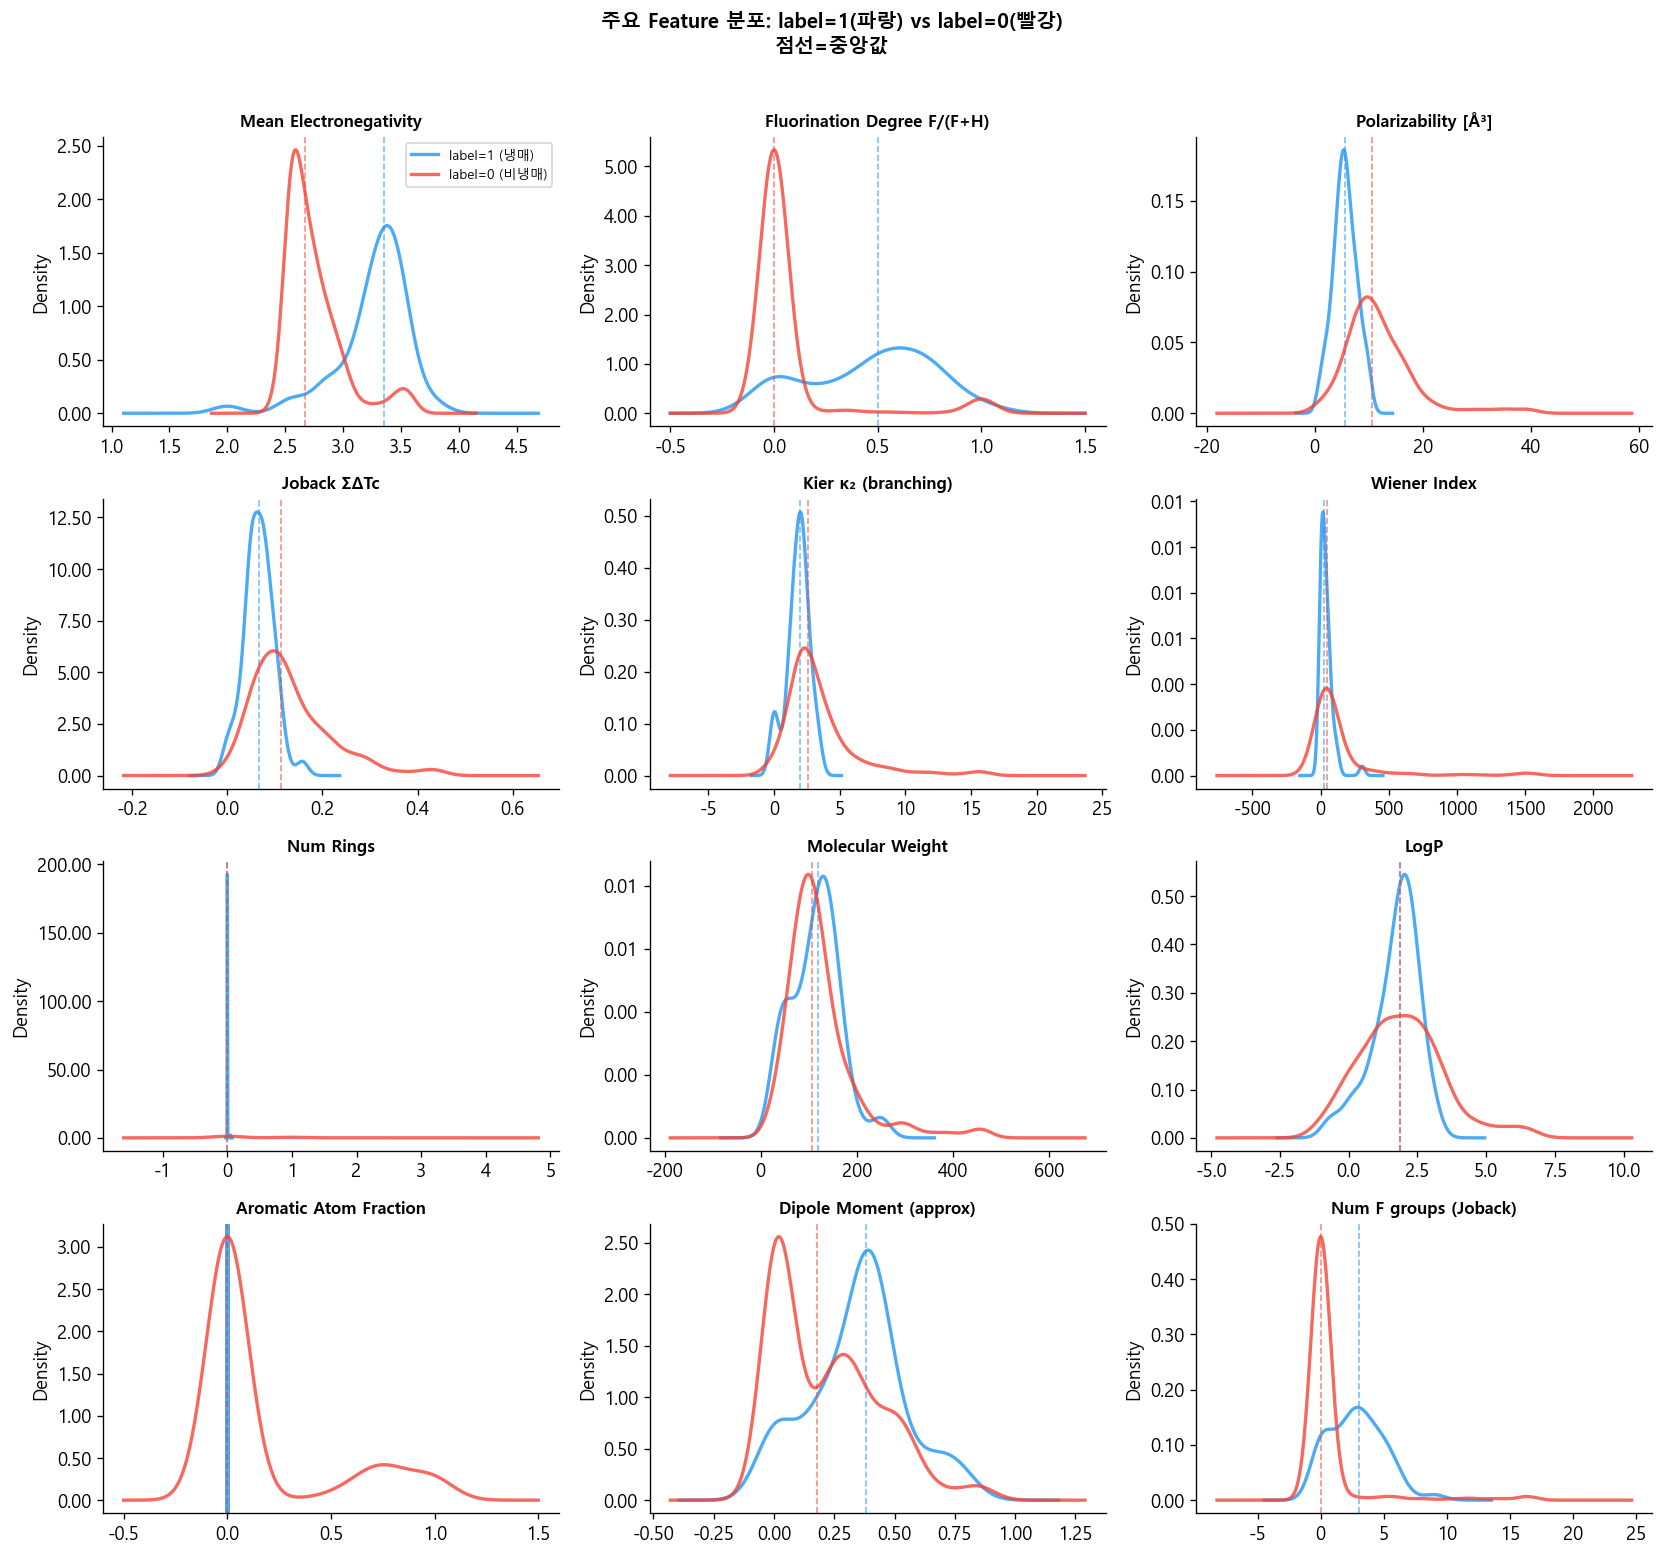

In [25]:
PLOT_FEATS = [
    ('el_en_mean',            'Mean Electronegativity'),
    ('rf_fluorination_degree','Fluorination Degree F/(F+H)'),
    ('el_polarizability',     'Polarizability [Å³]'),
    ('gc_sum_dTc',            'Joback ΣΔTc'),
    ('gt_kappa2',             'Kier κ₂ (branching)'),
    ('gt_wiener',             'Wiener Index'),
    ('gt_n_rings',            'Num Rings'),
    ('gt_mw',                 'Molecular Weight'),
    ('el_logP',               'LogP'),
    ('lg_mean_is_aromatic',   'Aromatic Atom Fraction'),
    ('el_dipole_gasteiger',   'Dipole Moment (approx)'),
    ('gc_F',                  'Num F groups (Joback)'),
]

n_cols = 3
n_rows = (len(PLOT_FEATS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()

for i, (feat, title) in enumerate(PLOT_FEATS):
    ax = axes[i]
    for lbl in [1, 0]:
        vals = feat_clean[feat_clean['label'] == lbl][feat].dropna()
        q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clip = vals.clip(q1, q99)
        # 분산이 0이면 KDE 불가 → 히스토그램 fallback
        if vals_clip.std() < 1e-8:
            ax.axvline(vals_clip.iloc[0], color=COLORS[lbl],
                       linewidth=3, alpha=0.8, label=CAT_LABELS[lbl])
        else:
            try:
                vals_clip.plot.kde(ax=ax, label=CAT_LABELS[lbl],
                                   color=COLORS[lbl], alpha=0.8, linewidth=2)
            except Exception:
                ax.hist(vals_clip, bins=15, color=COLORS[lbl],
                        alpha=0.5, label=CAT_LABELS[lbl], density=True)
        ax.axvline(vals.median(), color=COLORS[lbl],
                   linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('주요 Feature 분포: label=1(파랑) vs label=0(빨강)\n점선=중앙값',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4-3. 냉매 유형 분포 (Cat5 유형 분류)

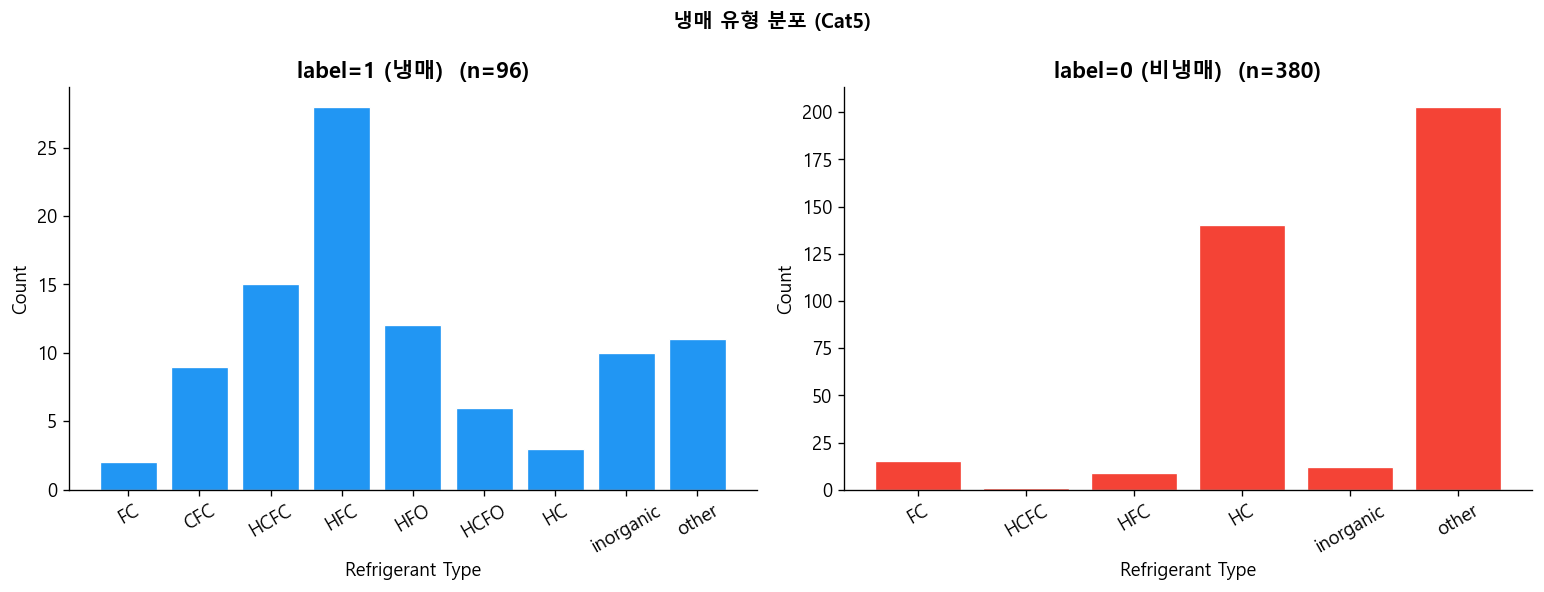

In [26]:
TYPE_COLS = [c for c in num_cols_clean if c.startswith('rf_type_')]
type_names = [c.replace('rf_type_', '') for c in TYPE_COLS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, lbl in zip(axes, [1, 0]):
    sub = feat_clean[feat_clean['label'] == lbl]
    counts = sub[TYPE_COLS].sum().values
    # 0인 유형 제외
    mask = counts > 0
    ax.bar(np.array(type_names)[mask], counts[mask],
           color=COLORS[lbl], edgecolor='white', linewidth=0.8)
    ax.set_title(f'{CAT_LABELS[lbl]}  (n={len(sub)})', fontweight='bold')
    ax.set_xlabel('Refrigerant Type')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('냉매 유형 분포 (Cat5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Feature 간 상관관계
### 5-1. 범주별 내부 상관 히트맵

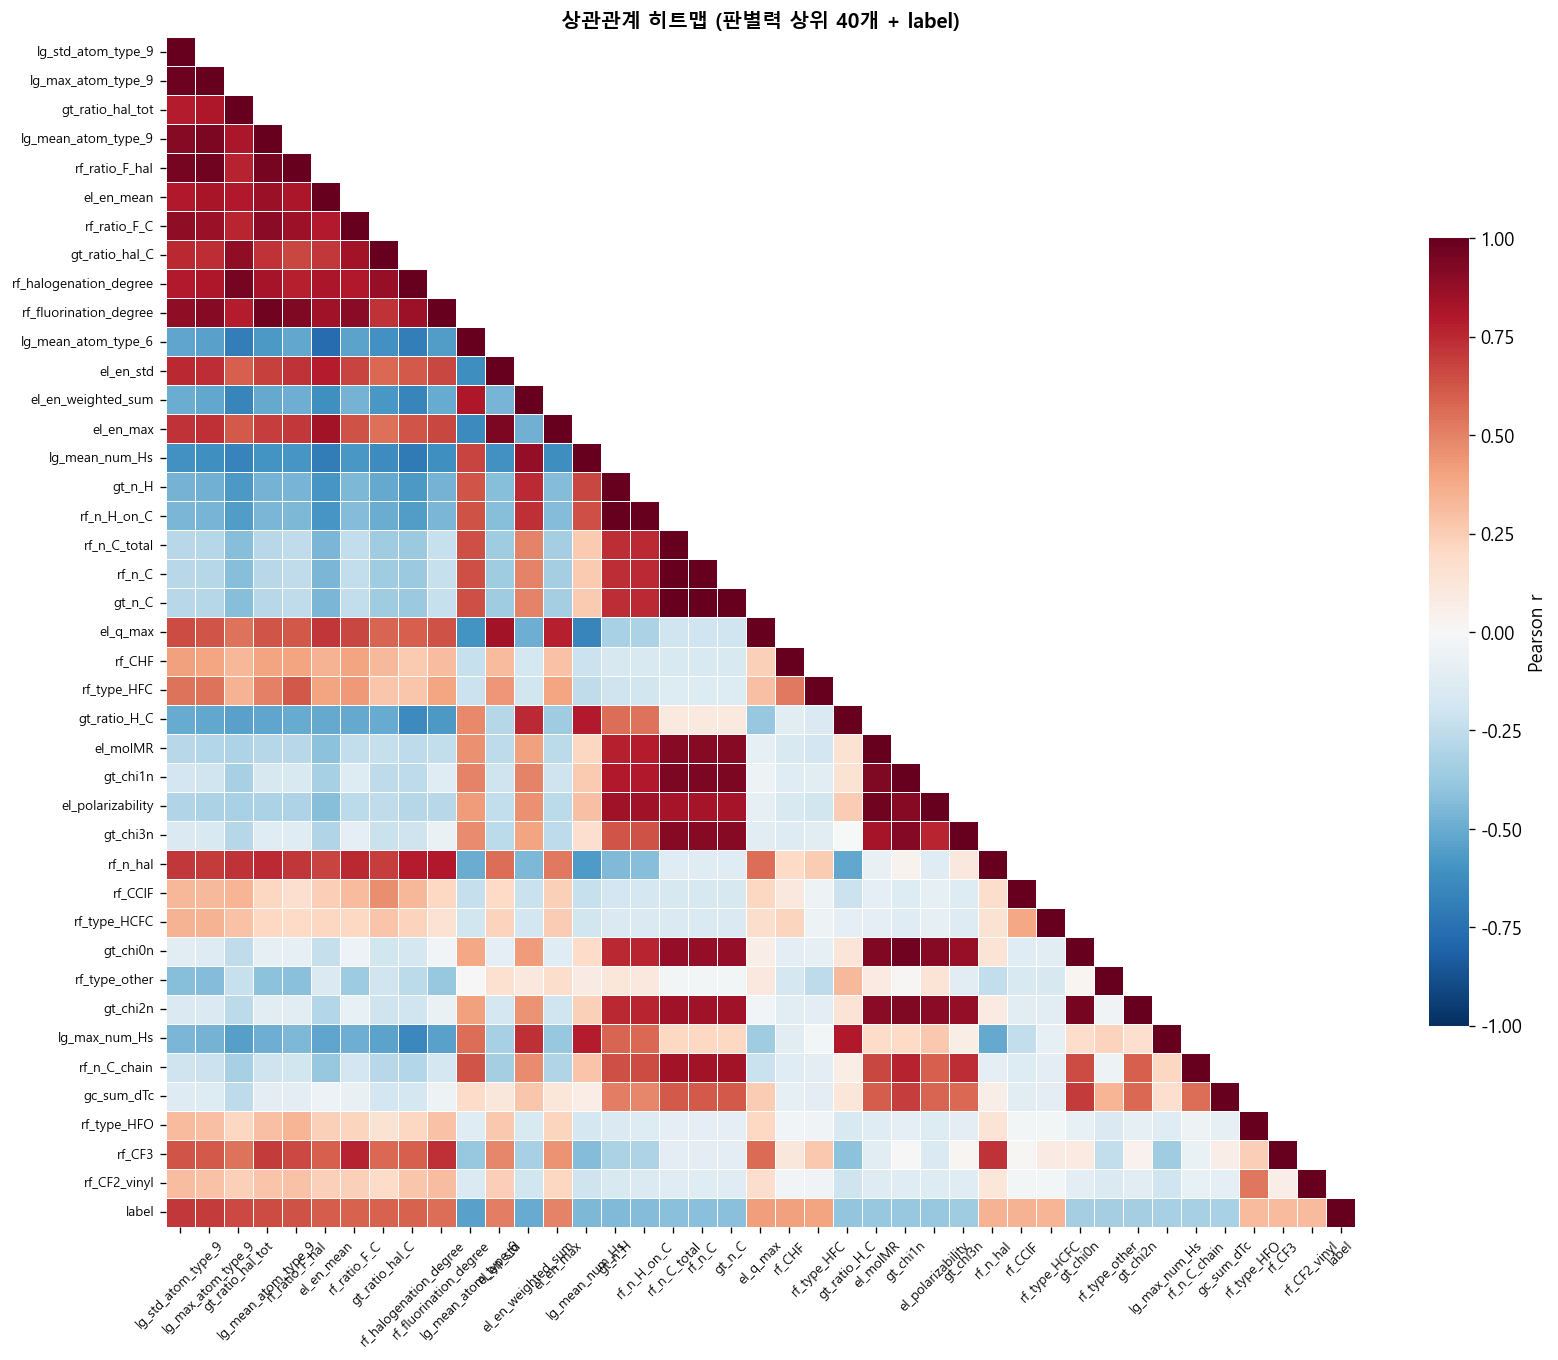

In [27]:
# 상관관계 히트맵: label 포함 상위 판별력 feature
top_feats = effect_size.head(40).index.tolist()
corr_df = feat_clean[top_feats + ['label']].copy()
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    annot=False, square=True,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}
)
ax.set_title('상관관계 히트맵 (판별력 상위 40개 + label)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

In [28]:
# 고상관 쌍 목록 (|r| > 0.85, label 제외)
feat_corr = feat_clean[top_feats].corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape, dtype=bool), k=1))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_A', 'level_1': 'feat_B', 0: 'abs_r'})
    .query('abs_r > 0.85')
    .sort_values('abs_r', ascending=False)
)
print(f'고상관 쌍 (|r| > 0.85): {len(high_corr)}개')
print(high_corr.to_string(index=False))

고상관 쌍 (|r| > 0.85): 54개
                feat_A                 feat_B    abs_r
          rf_n_C_total                 gt_n_C 1.000000
          rf_n_C_total                 rf_n_C 1.000000
                rf_n_C                 gt_n_C 1.000000
                gt_n_H            rf_n_H_on_C 0.996259
    lg_std_atom_type_9     lg_max_atom_type_9 0.984244
              el_molMR      el_polarizability 0.975222
              gt_chi1n               gt_chi0n 0.973814
   lg_mean_atom_type_9 rf_fluorination_degree 0.971564
    lg_max_atom_type_9         rf_ratio_F_hal 0.969677
              gt_chi0n               gt_chi2n 0.960520
   lg_mean_atom_type_9         rf_ratio_F_hal 0.959780
      gt_ratio_hal_tot rf_halogenation_degree 0.954215
    lg_std_atom_type_9         rf_ratio_F_hal 0.953706
             el_en_std              el_en_max 0.943129
    lg_max_atom_type_9    lg_mean_atom_type_9 0.941334
                rf_n_C               gt_chi1n 0.939144
                gt_n_C               gt_c

### 5-2. label과의 상관관계 (개별 feature)

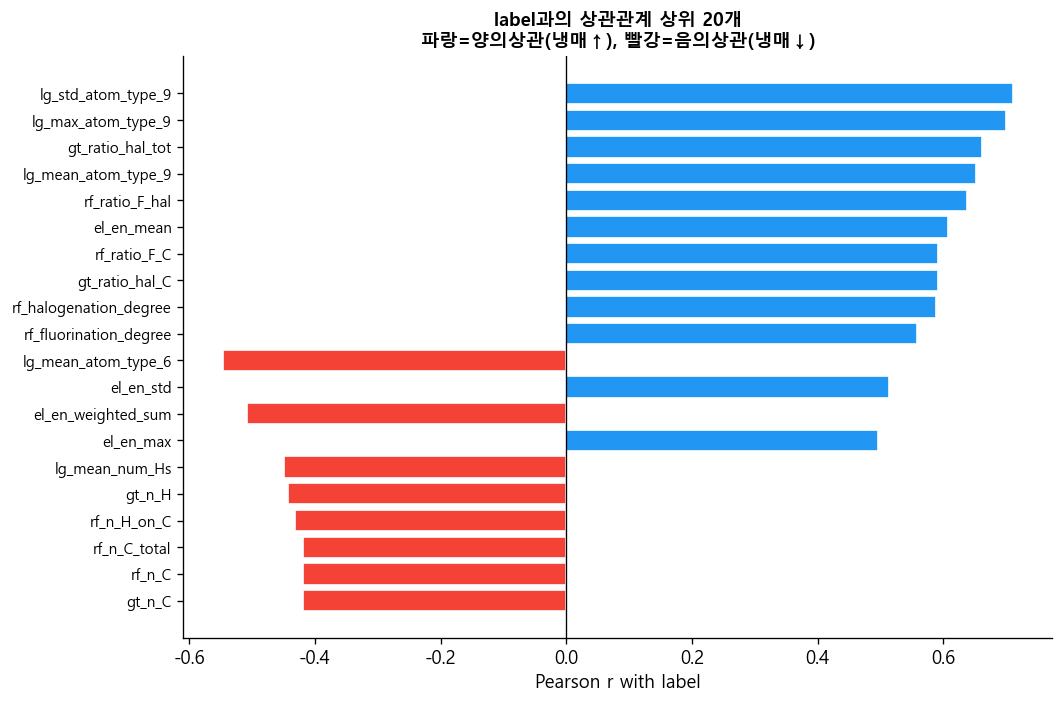

In [29]:
corr_with_label = feat_clean[num_cols_clean + ['label']].corr()['label'].drop('label')
corr_abs = corr_with_label.abs().sort_values(ascending=False)

top20 = corr_abs.head(20)
colors_bar = [PREFIX_COLOR.get(c.split('_')[0], '#90A4AE') for c in top20.index]

fig, ax = plt.subplots(figsize=(9, 6))
vals = corr_with_label[top20.index]
bar_colors2 = [COLORS[1] if v > 0 else COLORS[0] for v in vals]
ax.barh(range(len(top20)), vals.values, color=bar_colors2, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with label')
ax.set_title('label과의 상관관계 상위 20개\n파랑=양의상관(냉매↑), 빨강=음의상관(냉매↓)',
             fontsize=11, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Group별 분포
group 범주별로 feature 패턴이 얼마나 일관적인지 확인한다.

In [30]:
# group별 sample 수
group_counts = feat_clean.groupby(['group', 'label']).size().unstack(fill_value=0)
group_counts.columns = ['label=0', 'label=1']
group_counts['total'] = group_counts.sum(axis=1)
print(group_counts.sort_values('total', ascending=False).to_string())

                           label=0  label=1  total
group                                             
HCFC                             0       11     11
Cl_alkane_C3C5                   9        0      9
C7C9_branched_add                8        0      8
amine                            8        0      8
large_molecule_siloxane          8        0      8
long_chain_alcohol               8        0      8
branched_C7_alkane               8        0      8
aromatic_extended                7        0      7
Tc_too_high_nalkane              7        0      7
ester                            7        0      7
ester_add2                       7        0      7
ether_additional                 6        0      6
branched_C8_alkane               6        0      6
Tc_too_high_aromatic             6        0      6
H_bonding                        6        0      6
C3_doublebond_F                  0        6      6
halogenated_aromatic_add         6        0      6
ketone                         

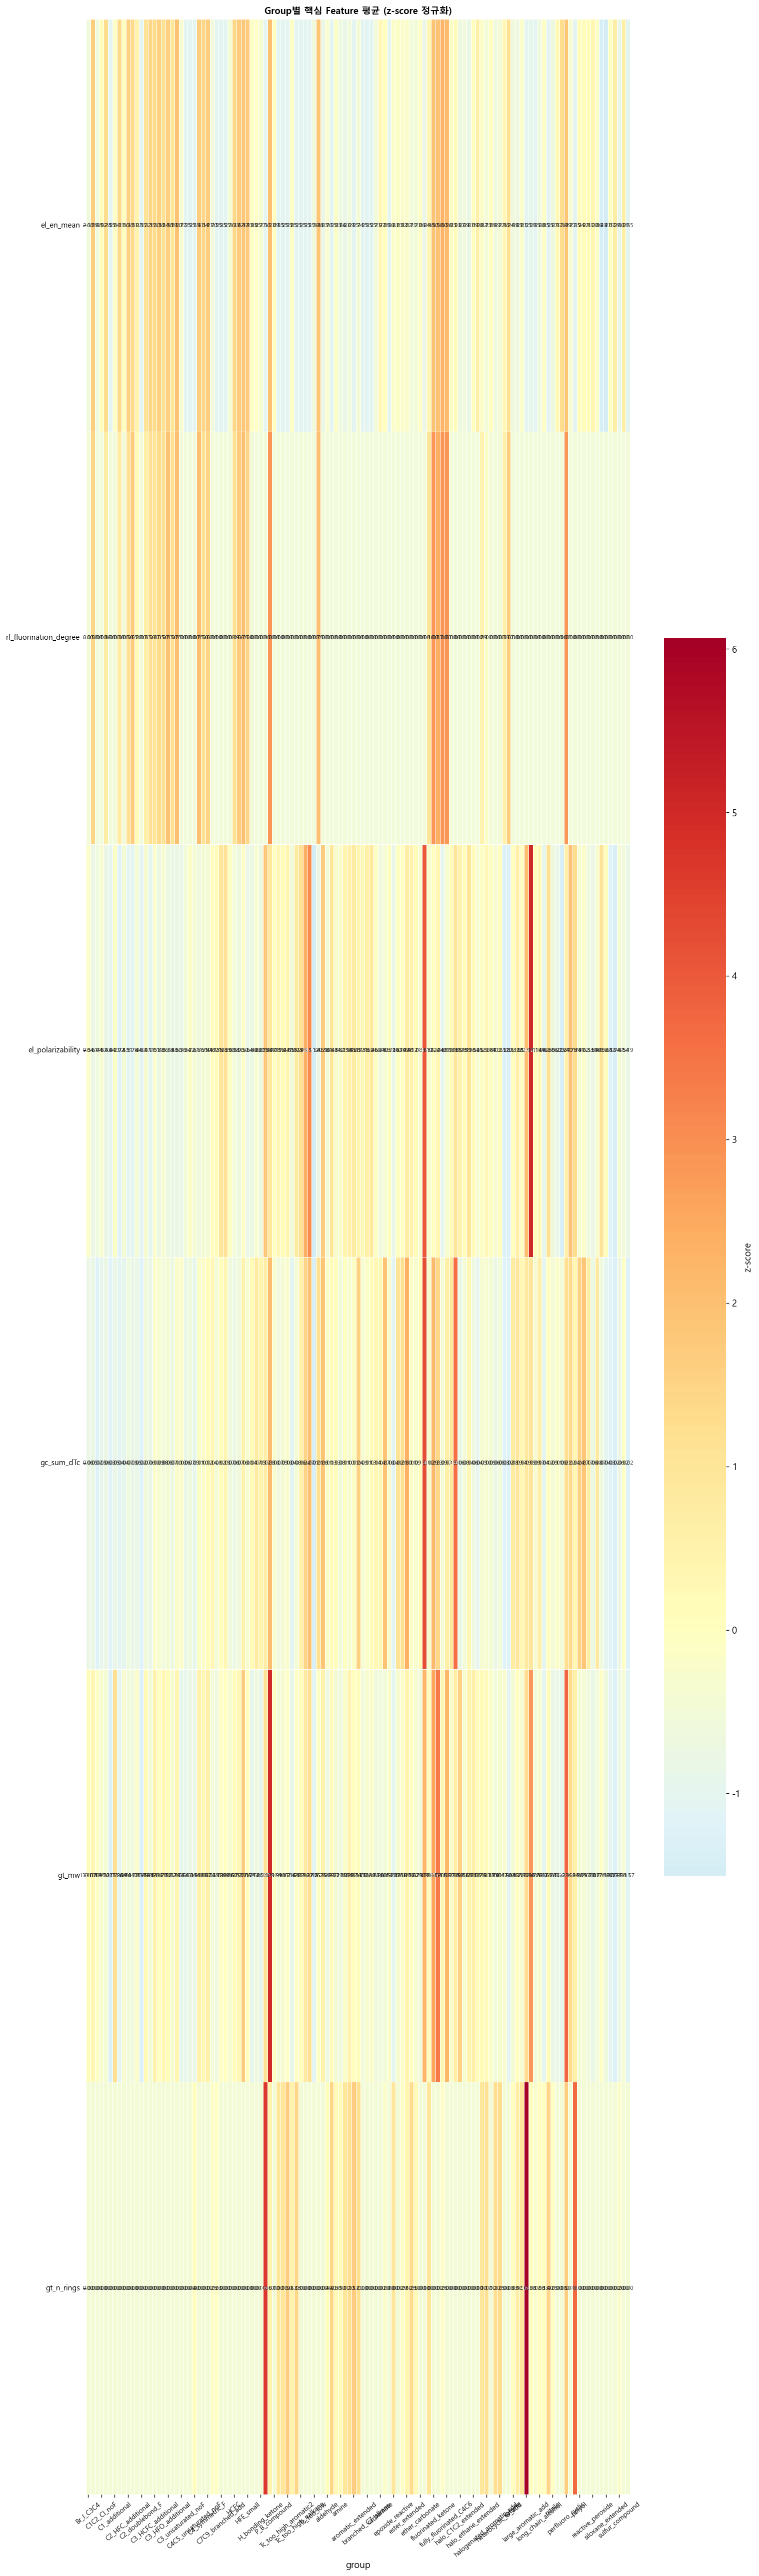

In [31]:
# group별 주요 feature 평균 비교
KEY = ['el_en_mean', 'rf_fluorination_degree', 'el_polarizability',
       'gc_sum_dTc', 'gt_mw', 'gt_n_rings']

grp_mean = feat_clean.groupby('group')[KEY].mean()
grp_mean_norm = (grp_mean - grp_mean.mean()) / (grp_mean.std() + 1e-8)

fig, ax = plt.subplots(figsize=(13, max(4, len(grp_mean) * 0.35)))
sns.heatmap(
    grp_mean_norm.T, ax=ax,
    cmap='RdYlBu_r', center=0,
    linewidths=0.3, linecolor='white',
    annot=grp_mean.T.round(2), fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'shrink': 0.5, 'label': 'z-score'}
)
ax.set_title('Group별 핵심 Feature 평균 (z-score 정규화)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

---
## 7. 이상값 (Outlier) 확인

In [32]:
# 각 feature에서 z-score > 4인 화합물
from scipy import stats

CHECK_FEATS = [
    'el_en_mean', 'el_polarizability', 'gc_sum_dTc',
    'gt_mw', 'gt_wiener', 'gt_kappa2', 'el_dipole_gasteiger'
]
outlier_records = []
for feat in CHECK_FEATS:
    vals = feat_clean[feat].dropna()
    z = np.abs(stats.zscore(vals))
    outlier_idx = vals.index[z > 4]
    for idx in outlier_idx:
        row = feat_clean.loc[idx]
        outlier_records.append({
            'feature': feat,
            'identifier': row['identifier'],
            'label': int(row['label']),
            'value': round(feat_clean.loc[idx, feat], 4),
            'z_score': round(z[z.index == idx].values[0], 2),
        })

outlier_df = pd.DataFrame(outlier_records).sort_values(['feature', 'z_score'], ascending=[True, False])
if len(outlier_df) == 0:
    print('이상값(z>4) 없음')
else:
    print(f'이상값 {len(outlier_df)}건:')
    display(outlier_df)

이상값 31건:


,feature,identifier,label,value,z_score
30,el_dipole_gasteiger,Nitroethane,0,1.1890,4.20
29,el_dipole_gasteiger,Nitromethane,0,1.1689,4.11
2,el_polarizability,MD4M,0,55.7330,6.55
4,el_polarizability,D6,0,51.8580,5.98
1,el_polarizability,MD3M,0,47.0900,5.29
3,el_polarizability,D5,0,43.2150,4.73
0,el_polarizability,MD2M,0,38.4470,4.03
7,gc_sum_dTc,Sorbitol,0,0.5480,5.19
6,gc_sum_dTc,MethylStearate,0,0.4696,4.24
5,gc_sum_dTc,MethylOleate,0,0.4576,4.09


---
## 8. Feature 선택 후보 정리
이후 모델 훈련에 사용할 feature 세트를 정리한다.

In [33]:
# 판별력 상위 + 범주별 균형을 맞춘 후보
CANDIDATE_FEATS = {
    'Cat1 (Group)':    [f for f in effect_size.index if f.startswith('gc_')][:10],
    'Cat2 (Graph)':    [f for f in effect_size.index if f.startswith('lg_')][:8],
    'Cat3 (Topology)': [f for f in effect_size.index if f.startswith('gt_')][:10],
    'Cat5 (Refrig)':   [f for f in effect_size.index if f.startswith('rf_')][:12],
    'Cat6 (Electr)':   [f for f in effect_size.index if f.startswith('el_')][:8],
}

all_candidates = []
print('=== Feature 후보 (판별력 기준 범주별 상위) ===')
for cat, feats in CANDIDATE_FEATS.items():
    print(f'\n{cat}')
    for f in feats:
        es = effect_size.get(f, 0)
        r  = corr_with_label.get(f, 0)
        print(f'  {f:<35} effect={es:.3f}  r={r:+.3f}')
        all_candidates.append(f)

print(f'\n총 후보 feature 수: {len(all_candidates)}개')

=== Feature 후보 (판별력 기준 범주별 상위) ===

Cat1 (Group)
  gc_sum_dTc                          effect=0.812  r=-0.326
  gc_F                                effect=0.748  r=+0.300
  gc_CH3                              effect=0.726  r=-0.291
  gc_CH2                              effect=0.507  r=-0.204
  gc_ar_CH                            effect=0.503  r=-0.202
  gc_Cl                               effect=0.491  r=+0.197
  gc_sum_dPc                          effect=0.459  r=-0.184
  gc_C                                effect=0.423  r=+0.170
  gc_ar_C                             effect=0.418  r=-0.168
  gc_O_other                          effect=0.408  r=-0.164

Cat2 (Graph)
  lg_std_atom_type_9                  effect=1.769  r=+0.710
  lg_max_atom_type_9                  effect=1.743  r=+0.700
  lg_mean_atom_type_9                 effect=1.621  r=+0.651
  lg_mean_atom_type_6                 effect=1.360  r=-0.546
  lg_mean_num_Hs                      effect=1.120  r=-0.450
  lg_max_num_Hs       

In [34]:
# 전처리된 feature 저장
CLEAN_PATH = os.path.join(DATA_DIR, 'features_clean.csv')
feat_clean.to_csv(CLEAN_PATH, index=False)
print(f'저장: {CLEAN_PATH}  shape={feat_clean.shape}')

# 요약
print()
print('=== 최종 요약 ===')
print(f'화합물 수:        {len(feat_clean)}')
print(f'총 feature 수:    {len(num_cols_clean)}')
print(f'제거된 feature:   gc_joback_Tc_K, gt_n_other (NaN 과다)')
print(f'NaN 대체:         비율 NaN → 0 (C=0 무기물 22종)')
print(f'가장 강한 판별:   {effect_size.index[0]} (effect={effect_size.iloc[0]:.3f})')

저장: c:\Users\user\Documents\STUDY\Refrigerant_Prediction\data\processed\features_clean.csv  shape=(476, 238)

=== 최종 요약 ===
화합물 수:        476
총 feature 수:    235
제거된 feature:   gc_joback_Tc_K, gt_n_other (NaN 과다)
NaN 대체:         비율 NaN → 0 (C=0 무기물 22종)
가장 강한 판별:   lg_std_atom_type_9 (effect=1.769)
